In [2]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import io
import json

def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Load baseline for comparison
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

print(f"Loaded {len(df)} trading days")
print(f"Baseline loaded for comparison")

Loaded 280 trading days
Baseline loaded for comparison


In [1]:
import torch
from chronos import ChronosBoltPipeline

model = ChronosBoltPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cpu",
    torch_dtype=torch.float32
)

print("Chronos-Bolt loaded successfully")
print("Faster and more accurate than original Chronos.")
print("Zero-shot — no training on your FX data needed.")

c:\Users\samik\fx-advisor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Chronos-Bolt loaded successfully
Faster and more accurate than original Chronos.
Zero-shot — no training on your FX data needed.


In [7]:
series = df['usd_inr'].dropna()
train = series[:-7]
actual = series[-7:]

context = torch.tensor(train.values, dtype=torch.float32)

quantiles, mean = model.predict_quantiles(
    inputs=context.unsqueeze(0),         # 'inputs' not 'context'
    prediction_length=7,
    quantile_levels=[0.1, 0.25, 0.5, 0.75, 0.9]
)

q = quantiles[0].numpy()
m = mean[0].numpy()

print(f"Forecast for next 7 days:\n")
print(f"{'Day':<6} {'Actual':<10} {'Median':<10} {'10th pctl':<10} {'90th pctl':<10} {'Naive':<10}")
print("-" * 56)

for i in range(7):
    print(f"Day {i+1:<3} {actual.iloc[i]:<10.4f} {q[i, 2]:<10.4f} {q[i, 0]:<10.4f} {q[i, 4]:<10.4f} {train.iloc[-1]:<10.4f}")



Forecast for next 7 days:

Day    Actual     Median     10th pctl  90th pctl  Naive     
--------------------------------------------------------
Day 1   95.6900    95.2311    94.4190    96.0699    95.2400   
Day 2   95.6900    95.4169    94.3996    96.4085    95.2400   
Day 3   95.7000    95.4986    94.2916    96.5881    95.2400   
Day 4   95.0000    95.5137    94.1619    96.7383    95.2400   
Day 5   94.9900    95.5415    94.0589    96.8726    95.2400   
Day 6   95.2700    95.6036    93.9893    97.0751    95.2400   
Day 7   95.7100    95.6346    93.8667    97.1995    95.2400   


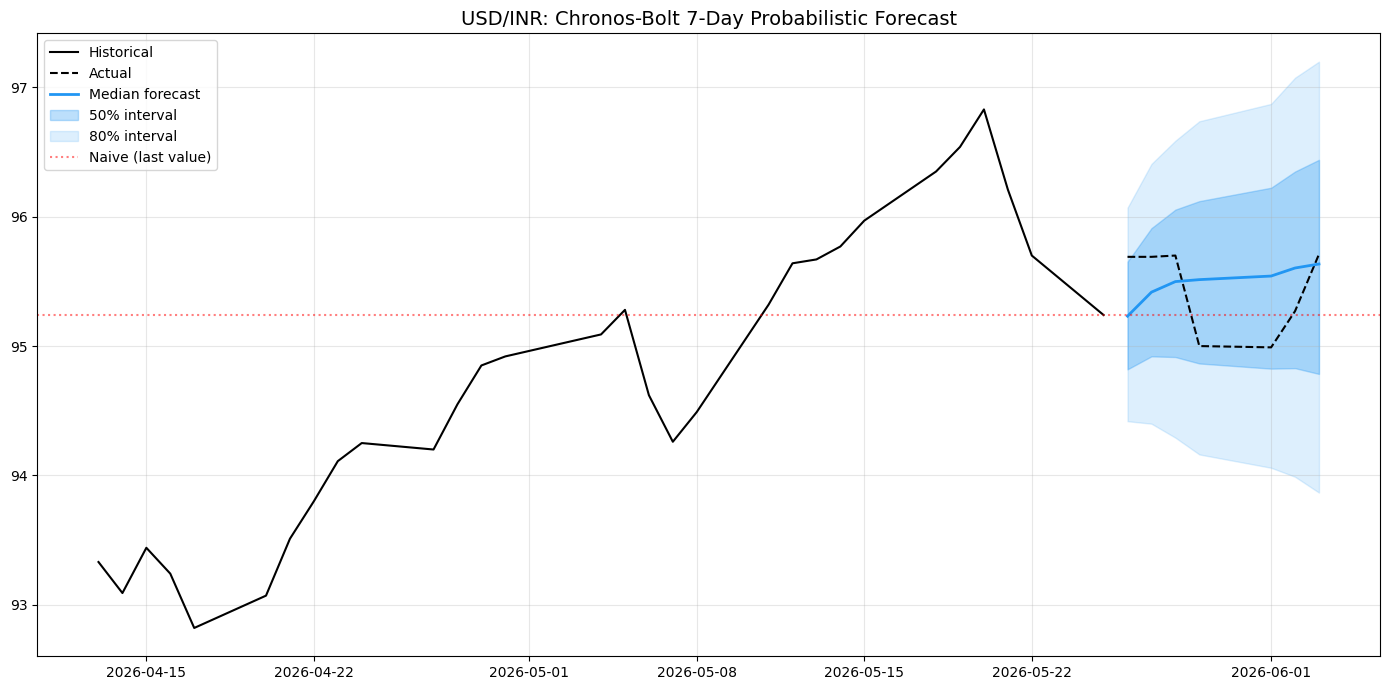

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

history = train[-30:]
ax.plot(history.index, history.values, color='black', linewidth=1.5, label='Historical')

future_dates = pd.bdate_range(start=train.index[-1] + pd.Timedelta(days=1), periods=7)

ax.plot(future_dates[:len(actual)], actual.values, color='black', linewidth=1.5,
        linestyle='--', label='Actual')

# q columns: [0.1, 0.25, 0.5, 0.75, 0.9]
ax.plot(future_dates, q[:, 2], color='#2196F3', linewidth=2, label='Median forecast')
ax.fill_between(future_dates, q[:, 1], q[:, 3], alpha=0.3, color='#2196F3', label='50% interval')
ax.fill_between(future_dates, q[:, 0], q[:, 4], alpha=0.15, color='#2196F3', label='80% interval')

ax.axhline(train.iloc[-1], color='red', linestyle=':', alpha=0.5, label='Naive (last value)')

ax.set_title('USD/INR: Chronos-Bolt 7-Day Probabilistic Forecast', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chronos_forecast_usdinr.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
def walk_forward_evaluate(series, model, forecast_horizon=1, test_days=60):
    """
    Walk-forward: for each day in test period, use all prior data
    to forecast the next day, then compare against actual.
    """
    series = series.dropna()
    
    if len(series) < test_days + 90:
        return None
    
    results = []
    
    for i in range(test_days, 0, -1):
        train = series[:-i]
        actual_value = series.iloc[-i]
        naive_value = train.iloc[-1]
        
        context = torch.tensor(train.values, dtype=torch.float32)
        
        with torch.no_grad():
            quantiles, mean_pred = model.predict_quantiles(
                inputs=context.unsqueeze(0),
                prediction_length=forecast_horizon,
                quantile_levels=[0.1, 0.3, 0.5, 0.7, 0.9]
            )
        
        q = quantiles[0, 0].numpy()  # first step, all quantiles
        forecast_median = q[2]       # 50th percentile
        
        # Direction prediction: does median forecast predict up or down?
        actual_direction = 1 if actual_value > train.iloc[-1] else 0
        forecast_direction = 1 if forecast_median > train.iloc[-1] else 0
        
        # Probability of increase: proportion of upper quantiles above current
        # Using quantile levels as rough probability estimate
        prob_increase = 0
        for qi, ql in zip(q, [0.1, 0.3, 0.5, 0.7, 0.9]):
            if qi > train.iloc[-1]:
                prob_increase += 0.2  # each quantile represents ~20% of distribution
        
        results.append({
            'date': series.index[-i],
            'actual': actual_value,
            'naive': naive_value,
            'forecast': forecast_median,
            'naive_error': abs(actual_value - naive_value),
            'forecast_error': abs(actual_value - forecast_median),
            'actual_direction': actual_direction,
            'forecast_direction': forecast_direction,
            'prob_increase': prob_increase,
            'q10': q[0],
            'q90': q[4]
        })
    
    return pd.DataFrame(results)

print("Running walk-forward evaluation (60 test days per pair)...")
print("This will take 5-10 minutes...\n")

evaluation = {}
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"Evaluating {col.upper()}...", end=" ", flush=True)
    result = walk_forward_evaluate(df[col], model, forecast_horizon=1, test_days=60)
    if result is not None:
        evaluation[col] = result
        print(f"done — {len(result)} forecasts")
    else:
        print("skipped — insufficient data")

print("\nAll evaluations complete")

Running walk-forward evaluation (60 test days per pair)...
This will take 5-10 minutes...

Evaluating USD_INR... done — 60 forecasts
Evaluating USD_EUR... done — 60 forecasts
Evaluating USD_GBP... done — 60 forecasts
Evaluating USD_MXN... done — 60 forecasts
Evaluating USD_PHP... done — 60 forecasts

All evaluations complete


In [13]:
print("=== Chronos vs Naive Baseline (1-day ahead forecast) ===\n")

comparison_rows = []

for col, result in evaluation.items():
    naive_mae = result['naive_error'].mean()
    chronos_mae = result['forecast_error'].mean()
    naive_mape = (result['naive_error'] / result['actual']).mean() * 100
    chronos_mape = (result['forecast_error'] / result['actual']).mean() * 100
    
    # Theil U: ratio of model error to naive error. < 1 means model wins
    theil_u = chronos_mae / naive_mae
    
    # Direction accuracy
    direction_acc = (result['actual_direction'] == result['forecast_direction']).mean() * 100
    
    comparison_rows.append({
        'pair': col.upper(),
        'naive_mae': naive_mae,
        'chronos_mae': chronos_mae,
        'theil_u': theil_u,
        'naive_mape': naive_mape,
        'chronos_mape': chronos_mape,
        'direction_accuracy': direction_acc,
        'verdict': 'CHRONOS WINS' if theil_u < 0.99 else 'NAIVE WINS' if theil_u > 1.01 else 'TIE'
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('pair')
print(comparison_df[['naive_mape', 'chronos_mape', 'theil_u', 'direction_accuracy', 'verdict']].round(4).to_string())

print(f"\n=== Key Metrics ===")
print(f"Theil U < 1.0: Chronos beats naive baseline")
print(f"Theil U = 1.0: No improvement over naive")
print(f"Theil U > 1.0: Naive is actually better")
print(f"Direction accuracy > 50%: Better than random guessing")

=== Chronos vs Naive Baseline (1-day ahead forecast) ===

         naive_mape  chronos_mape  theil_u  direction_accuracy       verdict
pair                                                                        
USD_INR      0.3409        0.3391   0.9939             63.3333           TIE
USD_EUR      0.2795        0.2960   1.0590             46.6667    NAIVE WINS
USD_GBP      0.3170        0.3193   1.0065             51.6667           TIE
USD_MXN      0.4525        0.4369   0.9662             53.3333  CHRONOS WINS
USD_PHP      0.3893        0.3870   0.9942             56.6667           TIE

=== Key Metrics ===
Theil U < 1.0: Chronos beats naive baseline
Theil U = 1.0: No improvement over naive
Theil U > 1.0: Naive is actually better
Direction accuracy > 50%: Better than random guessing


In [14]:
print("=== Probability Calibration Check ===\n")
print("When Chronos says '70% chance of increase', does it actually increase 70% of the time?\n")

for col, result in evaluation.items():
    # Bin probability predictions and check actual outcomes
    bins = [0, 0.3, 0.5, 0.7, 1.0]
    bin_labels = ['<30%', '30-50%', '50-70%', '>70%']
    
    result['prob_bin'] = pd.cut(result['prob_increase'], bins=bins, labels=bin_labels)
    
    print(f"{col.upper()}:")
    for label in bin_labels:
        subset = result[result['prob_bin'] == label]
        if len(subset) > 0:
            actual_increase_pct = subset['actual_direction'].mean() * 100
            count = len(subset)
            print(f"  Predicted {label:>5} chance of increase → actually increased {actual_increase_pct:.0f}% of the time ({count} days)")
    print()

print("Perfect calibration: predicted probability ≈ actual frequency")
print("If '70% predicted' → '70% actual', the probability bands are trustworthy")
print("If '70% predicted' → '50% actual', the model is overconfident")

=== Probability Calibration Check ===

When Chronos says '70% chance of increase', does it actually increase 70% of the time?

USD_INR:
  Predicted 30-50% chance of increase → actually increased 52% of the time (21 days)
  Predicted 50-70% chance of increase → actually increased 68% of the time (34 days)
  Predicted  >70% chance of increase → actually increased 100% of the time (5 days)

USD_EUR:
  Predicted  <30% chance of increase → actually increased 0% of the time (2 days)
  Predicted 30-50% chance of increase → actually increased 77% of the time (13 days)
  Predicted 50-70% chance of increase → actually increased 51% of the time (35 days)
  Predicted  >70% chance of increase → actually increased 50% of the time (10 days)

USD_GBP:
  Predicted 30-50% chance of increase → actually increased 67% of the time (6 days)
  Predicted 50-70% chance of increase → actually increased 53% of the time (49 days)
  Predicted  >70% chance of increase → actually increased 60% of the time (5 days)

U

In [16]:
# Save Chronos results
chronos_output = {}
for col, result in evaluation.items():
    naive_mae = result['naive_error'].mean()
    chronos_mae = result['forecast_error'].mean()
    
    chronos_output[col] = {
        'model': 'chronos-t5-small',
        'test_days': len(result),
        'naive_mae': float(naive_mae),
        'chronos_mae': float(chronos_mae),
        'theil_u': float(chronos_mae / naive_mae),
        'direction_accuracy': float((result['actual_direction'] == result['forecast_direction']).mean()),
        'naive_mape': float((result['naive_error'] / result['actual']).mean() * 100),
        'chronos_mape': float((result['forecast_error'] / result['actual']).mean() * 100)
    }

with open('chronos_results.json', 'w') as f:
    json.dump(chronos_output, f, indent=2)

print("Results saved to notebooks/chronos_results.json")
print("Will compare against DeepAR in notebook 05")

Results saved to notebooks/chronos_results.json
Will compare against DeepAR in notebook 05
